In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/sample_data/Crop_recommendation.csv")
df

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice
...,...,...,...,...,...,...,...,...
2195,107,34,32,26.774637,66.413269,6.780064,177.774507,coffee
2196,99,15,27,27.417112,56.636362,6.086922,127.924610,coffee
2197,118,33,30,24.131797,67.225123,6.362608,173.322839,coffee
2198,117,32,34,26.272418,52.127394,6.758793,127.175293,coffee


/tmp/ipykernel_13862/550409455.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['N'], color='orange')
/tmp/ipykernel_13862/550409455.py:10: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['P'], color='blue')
/tmp/ipykernel_13862/550409455.py:14: UserWarning: 

`distplot` is a deprecated f

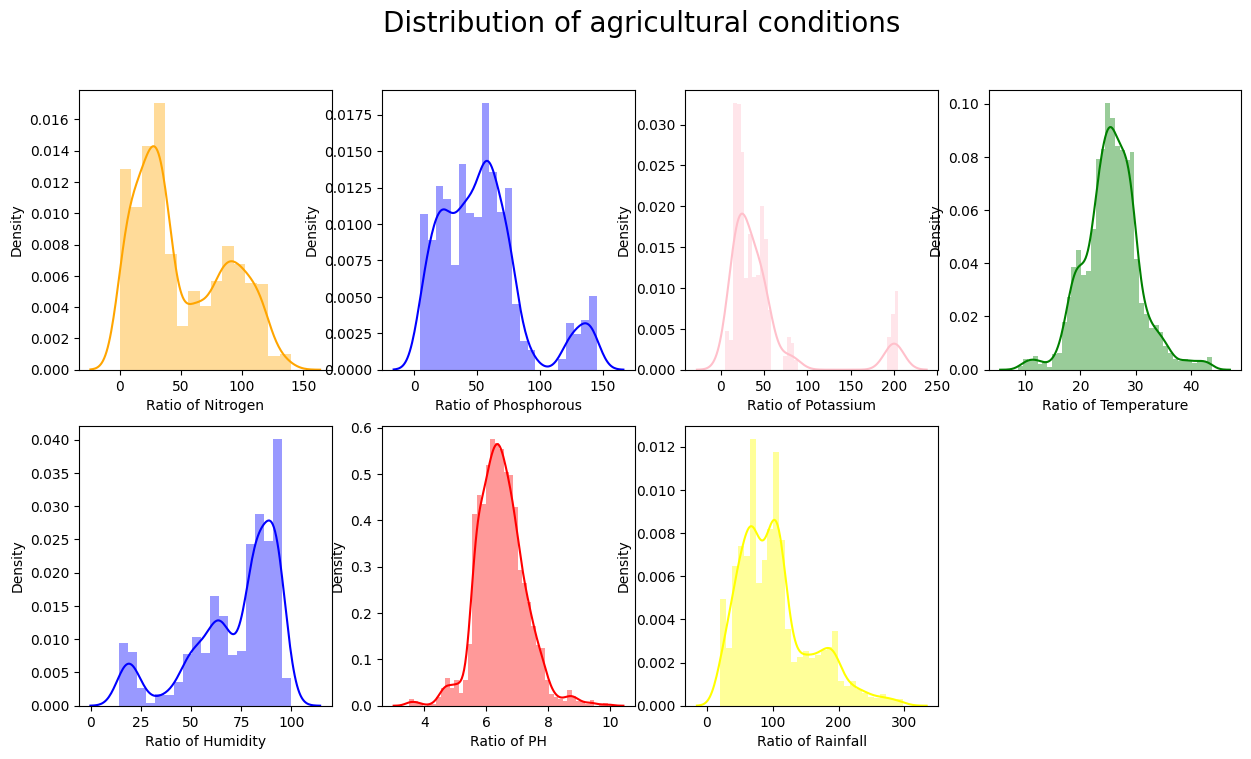

In [3]:
# Univariate Analysis

plt.rcParams['figure.figsize'] = (15, 8)

plt.subplot(2, 4, 1)
sns.distplot(df['N'], color='orange')
plt.xlabel('Ratio of Nitrogen')

plt.subplot(2, 4, 2)
sns.distplot(df['P'], color='blue')
plt.xlabel('Ratio of Phosphorous')

plt.subplot(2, 4, 3)
sns.distplot(df['K'], color='pink')
plt.xlabel('Ratio of Potassium')

plt.subplot(2, 4, 4)
sns.distplot(df['temperature'], color='green')
plt.xlabel('Ratio of Temperature')

plt.subplot(2, 4, 5)
sns.distplot(df['humidity'], color='blue')
plt.xlabel('Ratio of Humidity')

plt.subplot(2, 4, 6)
sns.distplot(df['ph'], color='red')
plt.xlabel('Ratio of PH')

plt.subplot(2, 4, 7)
sns.distplot(df['rainfall'], color='yellow')
plt.xlabel('Ratio of Rainfall')

plt.suptitle('Distribution of agricultural conditions', fontsize=20)
plt.show()

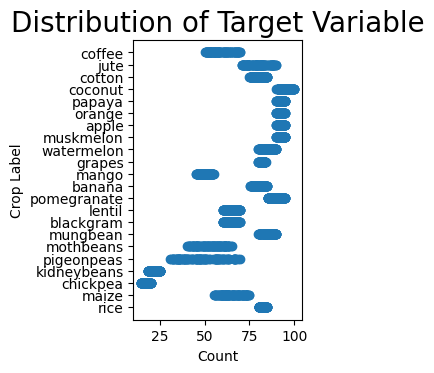

In [4]:
import seaborn as sns

# Analysis of Target Variable

plt.rcParams['figure.figsize'] = (10, 8)
plt.subplot(2, 4, 7)

plt.scatter(x = df['humidity'],y=df['label'])

plt.title('Distribution of Target Variable', fontsize=20)
plt.xlabel('Count')
plt.ylabel('Crop Label')

plt.show()

<Axes: ylabel='count'>

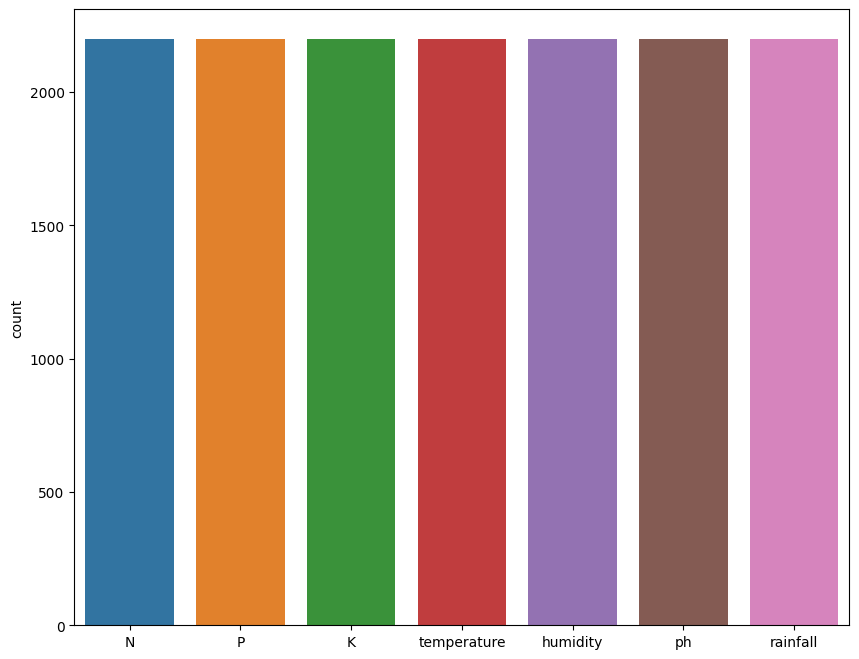

In [5]:
sns.countplot(df)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [7]:
df.isnull().sum()

,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


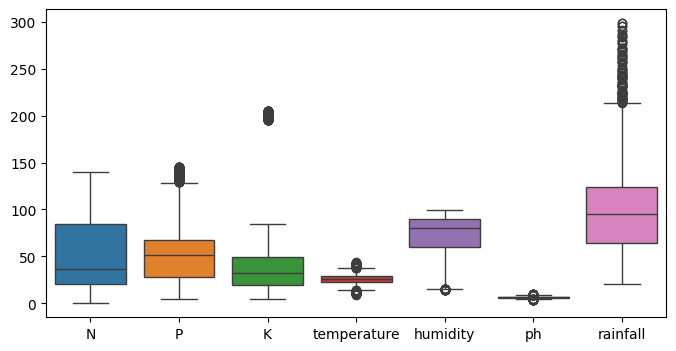

In [8]:
plt.figure(figsize=(8, 4))
sns.boxplot(df)
plt.show()

In [9]:
Q1 = df["P"].quantile(0.25)
Q3 = df["P"].quantile(0.75)
IQR = Q3 - Q1

filter = (df["P"] >= Q1 - 1.5 * IQR) & (df["P"] <= Q3 + 1.5 *IQR)
df = df.loc[filter]

In [10]:
df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2062.000000,2062.000000,2062.000000,2062.000000,2062.000000,2062.000000,2062.000000
mean,52.440349,47.706596,37.996605,25.770363,70.433297,6.502347,104.286486
std,37.246143,25.479349,33.049629,4.885812,22.569963,0.785073,56.385635
min,0.000000,5.000000,5.000000,9.724458,14.258040,3.504752,20.211267
25%,22.000000,27.000000,20.000000,23.080864,58.469697,6.016597,62.940621
50%,39.000000,48.000000,30.000000,25.768297,79.175605,6.469677,94.772563
75%,87.000000,64.000000,46.000000,28.614586,89.130631,6.956328,132.787974
max,140.000000,128.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [11]:
print("Summer Crops:")
print(df[(df["temperature"] > 30) & (df["humidity"] > 50)]["label"].unique())
print("---------------------------------------------------------------------")
print("Winter Crops:")
print(df[(df["temperature"] < 20) & (df["humidity"] > 30)]["label"].unique())
print("---------------------------------------------------------------------")
print("Rainy Crops:")
print(df[(df["rainfall"] > 200) & (df['humidity'] > 50)]["label"].unique())
print("---------------------------------------------------------------------")

Summer Crops:
['pigeonpeas' 'mothbeans' 'blackgram' 'mango' 'grapes' 'orange' 'papaya']
---------------------------------------------------------------------
Winter Crops:
['maize' 'pigeonpeas' 'lentil' 'pomegranate' 'grapes' 'orange']
---------------------------------------------------------------------
Rainy Crops:
['rice' 'papaya' 'coconut']
---------------------------------------------------------------------


In [12]:
print(df["label"].unique())

['rice' 'maize' 'chickpea' 'kidneybeans' 'pigeonpeas' 'mothbeans'
 'mungbean' 'blackgram' 'lentil' 'pomegranate' 'banana' 'mango' 'grapes'
 'watermelon' 'muskmelon' 'apple' 'orange' 'papaya' 'coconut' 'cotton'
 'jute' 'coffee']


In [13]:
le1 = LabelEncoder()
df["label"] = le1.fit_transform(df["label"])

/tmp/ipykernel_13862/1157598425.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["label"] = le1.fit_transform(df["label"])


In [14]:
for i, crop in enumerate(le1.classes_):
  print(i, crop)

0 apple
1 banana
2 blackgram
3 chickpea
4 coconut
5 coffee
6 cotton
7 grapes
8 jute
9 kidneybeans
10 lentil
11 maize
12 mango
13 mothbeans
14 mungbean
15 muskmelon
16 orange
17 papaya
18 pigeonpeas
19 pomegranate
20 rice
21 watermelon


In [15]:
X = df.drop("label", axis = 1)
y = df["label"]

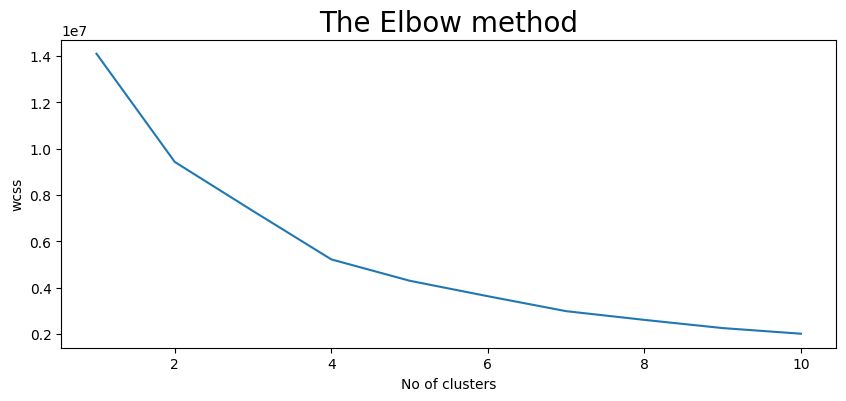

In [16]:
#el-bow method used to find out no of clusters and determine the optimum number of clusters within the dataset.
plt.rcParams['figure.figsize'] = (10,4)
wcss = []

for i in range(1,11):
    km = KMeans(n_clusters=i, init="k-means++", max_iter=300, n_init=10, random_state=0)
    km.fit(X)
    wcss.append(km.inertia_)

plt.plot(range(1,11), wcss)
plt.title("The Elbow method", fontsize=20)
plt.xlabel("No of clusters")
plt.ylabel("wcss")
plt.show()

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 42)

In [18]:
rfc = RandomForestClassifier()
rfc.fit(X_train, y_train)
y_pred = rfc.predict(X_test)

In [19]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        20
           2       1.00      1.00      1.00        29
           3       1.00      1.00      1.00        27
           4       1.00      1.00      1.00        28
           5       1.00      1.00      1.00        28
           6       1.00      1.00      1.00        22
           7       1.00      1.00      1.00         9
           8       0.88      1.00      0.94        22
           9       1.00      1.00      1.00        33
          10       1.00      1.00      1.00        17
          11       1.00      1.00      1.00        23
          12       1.00      1.00      1.00        22
          13       1.00      1.00      1.00        29
          14       1.00      1.00      1.00        22
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        24
          17       1.00    

In [20]:
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [21]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        20
           2       0.94      1.00      0.97        29
           3       1.00      1.00      1.00        27
           4       1.00      1.00      1.00        28
           5       1.00      1.00      1.00        28
           6       0.96      1.00      0.98        22
           7       1.00      1.00      1.00         9
           8       0.86      0.86      0.86        22
           9       0.94      1.00      0.97        33
          10       0.94      1.00      0.97        17
          11       1.00      0.96      0.98        23
          12       1.00      1.00      1.00        22
          13       1.00      0.97      0.98        29
          14       1.00      1.00      1.00        22
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        24
          17       1.00    

In [22]:
dtc = DecisionTreeClassifier()
dtc.fit(X_train, y_train)
y_pred = dtc.predict(X_test)

In [23]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        20
           2       0.97      1.00      0.98        29
           3       1.00      1.00      1.00        27
           4       1.00      1.00      1.00        28
           5       1.00      1.00      1.00        28
           6       0.96      1.00      0.98        22
           7       1.00      1.00      1.00         9
           8       0.88      1.00      0.94        22
           9       1.00      1.00      1.00        33
          10       0.89      1.00      0.94        17
          11       1.00      0.96      0.98        23
          12       1.00      1.00      1.00        22
          13       1.00      0.90      0.95        29
          14       1.00      1.00      1.00        22
          15       1.00      1.00      1.00        23
          16       1.00      0.96      0.98        24
          17       1.00    

In [24]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.95      1.00      0.98        20
           2       0.84      0.90      0.87        29
           3       1.00      1.00      1.00        27
           4       0.90      1.00      0.95        28
           5       1.00      1.00      1.00        28
           6       0.88      0.95      0.91        22
           7       1.00      1.00      1.00         9
           8       0.85      1.00      0.92        22
           9       1.00      1.00      1.00        33
          10       0.84      0.94      0.89        17
          11       0.94      0.74      0.83        23
          12       0.96      1.00      0.98        22
          13       0.96      0.79      0.87        29
          14       0.92      1.00      0.96        22
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        24
          17       1.00    

In [26]:
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(accuracy_score(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.95      1.00      0.98        20
           2       0.84      0.90      0.87        29
           3       1.00      1.00      1.00        27
           4       0.90      1.00      0.95        28
           5       1.00      1.00      1.00        28
           6       0.88      0.95      0.91        22
           7       1.00      1.00      1.00         9
           8       0.85      1.00      0.92        22
           9       1.00      1.00      1.00        33
          10       0.84      0.94      0.89        17
          11       0.94      0.74      0.83        23
          12       0.96      1.00      0.98        22
          13       0.96      0.79      0.87        29
          14       0.92      1.00      0.96        22
          15       1.00      1.00      1.00        23
          16       1.00      1.00      1.00        24
          17       1.00    

In [27]:
label = rfc.predict([[90, 42, 43, 20.879744, 82.002744, 6.502985, 202.935536]])
print(f"Predicted crop: {le1.classes_[label][0]}")

Predicted crop: rice


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [28]:
import joblib

In [29]:
joblib.dump(lr, "crop_recommendation_model.pkl")

['crop_recommendation_model.pkl']

In [30]:
joblib.dump(le1, "crop_recommendation_label_encoder.pkl")

['crop_recommendation_label_encoder.pkl']